# Latent Dynamics Estimation on a Synthetic Generator
# 2.1. Synthetic generator on the two-sphere

In [1]:
import numpy as np

Parameters

In [72]:
mu    = np.array([0,0,1])
kappa = 0.5
sigma = 0.2
dt    = 0.01
T     = 100
d     = 2

def simulate_ou_on_sphere(mu = np.array([0,0,1]),
                          kappa: float = 0.5,
                          sigma: float = 0.2,
                          dt:float = 0.01,
                          T: int = 100,
                          d: int = 2):
    
    # Generating the latent process Yt
    Y = np.zeros(shape=(T,d))
    Y[0] = np.random.multivariate_normal(mean=np.zeros(d), cov=np.eye(d))

    for t in range(1,T):
        xi = np.random.multivariate_normal(mean=np.zeros(d), cov=(np.eye(d)))
        Y[t] = Y[t-1] - kappa * Y[t-1] * dt + sigma * np.sqrt(dt) * xi

    # Projecting onto the sphere with the exponential map
    X = np.zeros(shape=(T, d+1))

    Y_norm = np.linalg.norm(Y, axis=1)

    X[:,0] = (np.sin(Y_norm)/Y_norm) * Y[:,0]
    X[:,1] = (np.sin(Y_norm)/Y_norm) * Y[:,1]
    X[:,2] = np.cos(Y_norm)

    return X, Y

X, Y = simulate_ou_on_sphere()


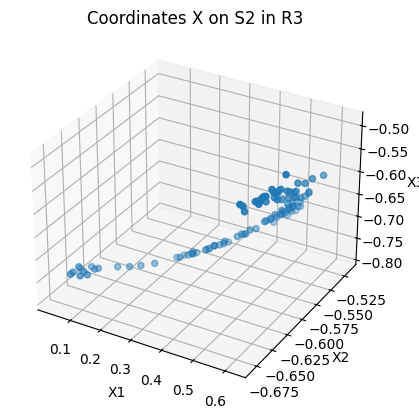

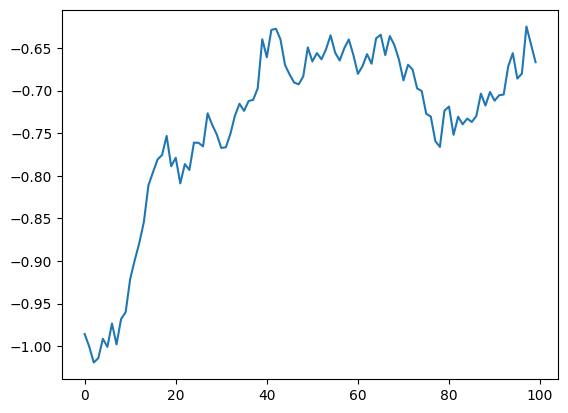

In [73]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 2], X[:, 1], X[:, 0], s=20)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Coordinates X on S2 in R3')
plt.show()
plt.plot(Y[:,1])

In [15]:
xi + Y[0]


array([[0.77727942, 0.34379034]])

In [16]:
Y[0]

array([0., 0.])